In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# SECTION A — DATA PREPROCESSING
# ==========================================

# 1. Load datasets
train_df = pd.read_csv("california_housing_train.csv")
test_df = pd.read_csv("california_housing_test.csv")

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training shape: (17000, 9)
Testing shape : (3000, 9)


# A. Data preprocessing

In [4]:

# 2. Separate features and target
target_column = "median_house_value"

X_train = train_df.drop(columns=[target_column]).values
y_train = train_df[target_column].values

X_test = test_df.drop(columns=[target_column]).values
y_test = test_df[target_column].values

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (17000, 8)
y_train shape: (17000,)
X_test shape : (3000, 8)
y_test shape : (3000,)


In [5]:
# 3. Standardize features
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("\nScaled training means:")
print(np.mean(X_train_scaled, axis=0))

print("\nScaled training standard deviations:")
print(np.std(X_train_scaled, axis=0))


Scaled training means:
[-6.63396135e-15  2.67498442e-17 -7.60698694e-17 -9.02807241e-17
 -8.69369936e-17  7.35620715e-17  2.00623831e-17 -3.64466627e-16]

Scaled training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# 4. Add intercept/bias column
X_train_final = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_final = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

In [7]:
print("\nFinal X_train shape:", X_train_final.shape)
print("Final X_test shape :", X_test_final.shape)


Final X_train shape: (17000, 9)
Final X_test shape : (3000, 9)


# B. Implement Normal Equation (closed-form)

In [8]:
# ==========================================
# SECTION B — NORMAL EQUATION
# ==========================================
def normal_equation(X, y):
    """
    Linear Regression using the Normal Equation.

    theta = (X^T X)^(-1) X^T y
    """

    X_transpose = X.T

    XTX = X_transpose @ X

    XTX_inverse = np.linalg.inv(XTX)

    XTy = X_transpose @ y

    theta = XTX_inverse @ XTy

    return theta


In [9]:
# ------------------------------------------
# Train Normal Equation
# ------------------------------------------

theta_normal = normal_equation(
    X_train_final,
    y_train
)

print("Theta values:")
print(theta_normal)

Theta values:
[207300.91235294 -86499.60728226 -91744.05083061  14483.29860201
 -18263.60700749  49587.33777166 -44178.15153005  17470.57604338
  77291.55314914]


In [10]:
# ------------------------------------------
# Predictions
# ------------------------------------------

y_train_pred_normal = X_train_final @ theta_normal

y_test_pred_normal = X_test_final @ theta_normal

In [11]:
# ------------------------------------------
# Evaluation Metrics
# ------------------------------------------

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def r2_score(y_true, y_pred):
    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_total = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_total)


# Training metrics
train_mse_normal = mean_squared_error(
    y_train,
    y_train_pred_normal
)

train_rmse_normal = root_mean_squared_error(
    y_train,
    y_train_pred_normal
)

train_r2_normal = r2_score(
    y_train,
    y_train_pred_normal
)


# Test metrics
test_mse_normal = mean_squared_error(
    y_test,
    y_test_pred_normal
)

test_rmse_normal = root_mean_squared_error(
    y_test,
    y_test_pred_normal
)

test_r2_normal = r2_score(
    y_test,
    y_test_pred_normal
)

In [12]:
# Training metrics
train_mse_normal = mean_squared_error(
    y_train,
    y_train_pred_normal
)

train_rmse_normal = root_mean_squared_error(
    y_train,
    y_train_pred_normal
)

train_r2_normal = r2_score(
    y_train,
    y_train_pred_normal
)


# Test metrics
test_mse_normal = mean_squared_error(
    y_test,
    y_test_pred_normal
)

test_rmse_normal = root_mean_squared_error(
    y_test,
    y_test_pred_normal
)

test_r2_normal = r2_score(
    y_test,
    y_test_pred_normal
)

In [13]:
# ------------------------------------------
# Display results
# ------------------------------------------

print("\n===== NORMAL EQUATION RESULTS =====")

print("\nTraining:")
print("MSE  :", train_mse_normal)
print("RMSE :", train_rmse_normal)
print("R²   :", train_r2_normal)

print("\nTest:")
print("MSE  :", test_mse_normal)
print("RMSE :", test_rmse_normal)
print("R²   :", test_r2_normal)


===== NORMAL EQUATION RESULTS =====

Training:
MSE  : 4824523173.926898
RMSE : 69458.78759326927
R²   : 0.6413378529502689

Test:
MSE  : 4867205486.928866
RMSE : 69765.36022216803
R²   : 0.6195057678311999


# C. Implement Batch Gradient Descent (iterative)

In [14]:
# ==========================================
# SECTION C — BATCH GRADIENT DESCENT
# ==========================================

def gradient_descent(X, y, learning_rate=0.01,
                     iterations=1000, tolerance=None):

    n = X.shape[0]

    # Initialize parameters
    theta = np.zeros(X.shape[1])

    # Store loss
    loss_history = []

    for i in range(iterations):

        # Predictions
        predictions = X @ theta

        # Error
        error = predictions - y

        # Loss
        loss = np.sum(error ** 2) / (2 * n)

        # Store loss
        loss_history.append(loss)

        # Gradient
        gradient = (X.T @ error) / n

        # Update parameters
        theta = theta - learning_rate * gradient

        # Early stopping
        if tolerance is not None and i > 0:

            loss_change = abs(
                loss_history[-2] -
                loss_history[-1]
            )

            if loss_change < tolerance:

                print(
                    f"Early stopping at iteration {i + 1}"
                )

                break

    return theta, loss_history

In [15]:

# ------------------------------------------
# Train model
# ------------------------------------------

theta_gd, loss_history = gradient_descent(
    X_train_final,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

In [16]:
# ------------------------------------------
# Predictions
# ------------------------------------------

y_train_pred_gd = X_train_final @ theta_gd
y_test_pred_gd = X_test_final @ theta_gd

In [17]:


# ------------------------------------------
# Metrics
# ------------------------------------------

train_mse_gd = mean_squared_error(
    y_train,
    y_train_pred_gd
)

train_rmse_gd = root_mean_squared_error(
    y_train,
    y_train_pred_gd
)

train_r2_gd = r2_score(
    y_train,
    y_train_pred_gd
)


test_mse_gd = mean_squared_error(
    y_test,
    y_test_pred_gd
)

test_rmse_gd = root_mean_squared_error(
    y_test,
    y_test_pred_gd
)

test_r2_gd = r2_score(
    y_test,
    y_test_pred_gd
)

In [18]:
print("\n===== GRADIENT DESCENT RESULTS =====")

print("\nTraining:")
print("MSE  :", train_mse_gd)
print("RMSE :", train_rmse_gd)
print("R²   :", train_r2_gd)

print("\nTest:")
print("MSE  :", test_mse_gd)
print("RMSE :", test_rmse_gd)
print("R²   :", test_r2_gd)


===== GRADIENT DESCENT RESULTS =====

Training:
MSE  : 5132650101.902221
RMSE : 71642.51602157913
R²   : 0.618431244034239

Test:
MSE  : 5149828415.410274
RMSE : 71762.30497559477
R²   : 0.5974116946603373


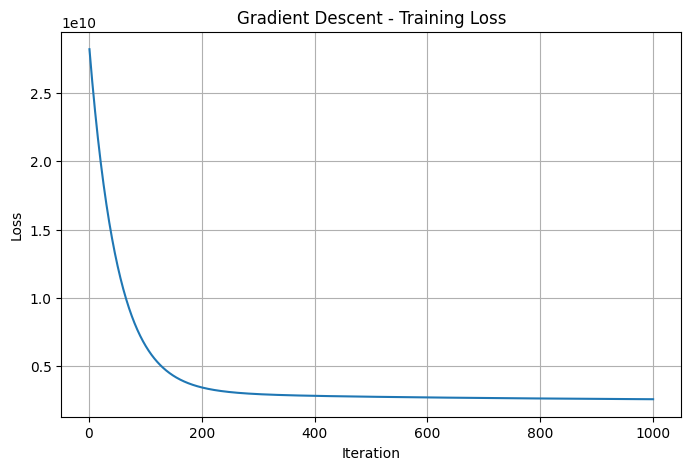

In [19]:
# ------------------------------------------
# Loss vs Iterations
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent - Training Loss")

plt.grid(True)
plt.savefig(
    "gradient_descent_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

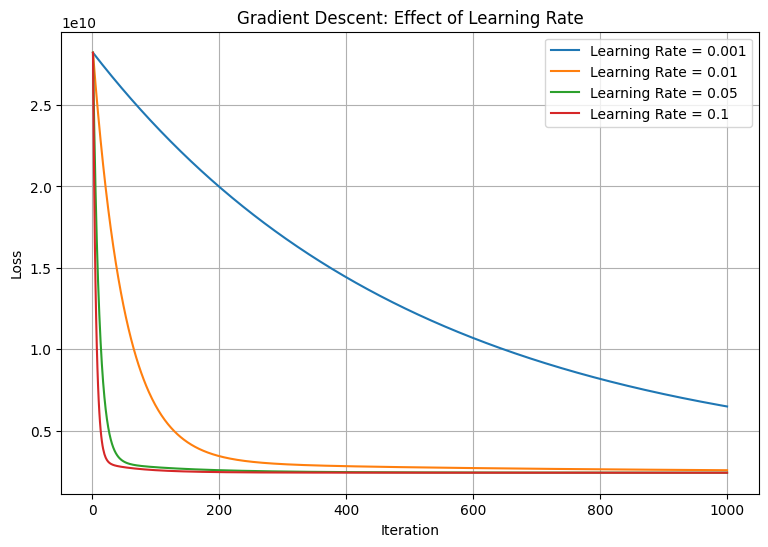

In [20]:
# ------------------------------------------
# Learning Rate Comparison
# ------------------------------------------

learning_rates = [0.001, 0.01, 0.05, 0.1]

loss_histories = {}

for lr in learning_rates:

    theta, losses = gradient_descent(
        X_train_final,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    loss_histories[lr] = losses


plt.figure(figsize=(9, 6))

for lr, losses in loss_histories.items():

    plt.plot(
        range(1, len(losses) + 1),
        losses,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent: Effect of Learning Rate")

plt.legend()
plt.grid(True)

plt.savefig(
    "gradient_descent_learning_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# E. Comparisons with scikit-learn

In [21]:
# ==========================================
# SECTION E — SCIKIT-LEARN COMPARISON
# ==========================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_test_pred_sklearn = model.predict(X_test_scaled)

In [23]:
test_mse_sklearn = mean_squared_error(
    y_test,
    y_test_pred_sklearn
)

test_rmse_sklearn = root_mean_squared_error(
    y_test,
    y_test_pred_sklearn
)

test_r2_sklearn = r2_score(
    y_test,
    y_test_pred_sklearn
)

print("===== SCIKIT-LEARN RESULTS =====")
print("MSE  :", test_mse_sklearn)
print("RMSE :", test_rmse_sklearn)
print("R²   :", test_r2_sklearn)

===== SCIKIT-LEARN RESULTS =====
MSE  : 4867205486.928865
RMSE : 69765.36022216803
R²   : 0.6195057678312


# Comparing all three models

In [24]:
results = pd.DataFrame({
    "Model": [
        "Normal Equation",
        "Gradient Descent",
        "Scikit-learn"
    ],
    "MSE": [
        test_mse_normal,
        test_mse_gd,
        test_mse_sklearn
    ],
    "RMSE": [
        test_rmse_normal,
        test_rmse_gd,
        test_rmse_sklearn
    ],
    "R2": [
        test_r2_normal,
        test_r2_gd,
        test_r2_sklearn
    ]
})

print(results)

              Model           MSE          RMSE        R2
0   Normal Equation  4.867205e+09  69765.360222  0.619506
1  Gradient Descent  5.149828e+09  71762.304976  0.597412
2      Scikit-learn  4.867205e+09  69765.360222  0.619506


# F. Visualizations

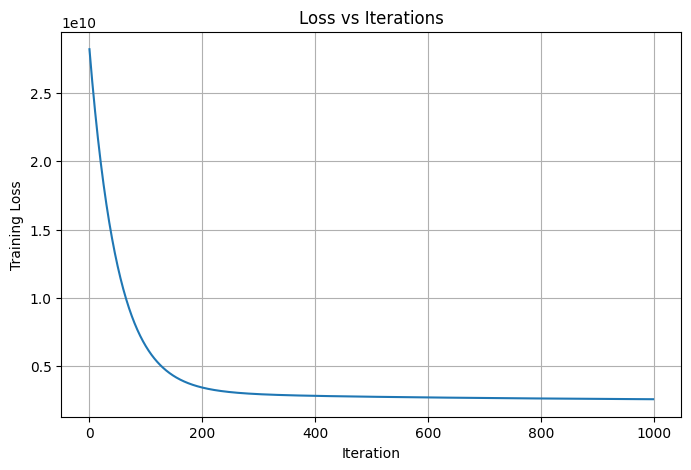

In [25]:
# ==========================================
# 1. Loss vs Iterations
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Loss vs Iterations")

plt.grid(True)
plt.savefig("loss_vs_iterations.png", dpi=300)
plt.show()

In [26]:
# ==========================================
# 2. Validation Loss
# ==========================================

validation_loss = mean_squared_error(
    y_test,
    y_test_pred_gd
)

print("Validation MSE:", validation_loss)

Validation MSE: 5149828415.410274


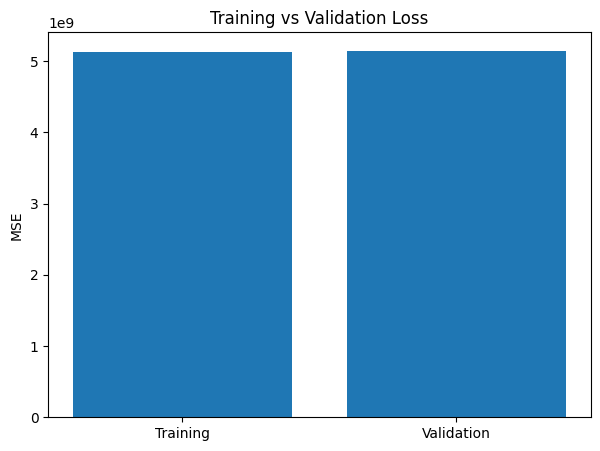

In [27]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Training", "Validation"],
    [
        mean_squared_error(y_train, y_train_pred_gd),
        validation_loss
    ]
)

plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.savefig("validation_loss.png", dpi=300)
plt.show()

In [28]:
# ==========================================
# 3. Loss Surface
# ==========================================

theta1 = np.linspace(
    theta_gd[1] - 2,
    theta_gd[1] + 2,
    50
)

theta2 = np.linspace(
    theta_gd[2] - 2,
    theta_gd[2] + 2,
    50
)

T1, T2 = np.meshgrid(theta1, theta2)

loss_surface = np.zeros(T1.shape)

for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):

        theta_temp = theta_gd.copy()

        theta_temp[1] = T1[i, j]
        theta_temp[2] = T2[i, j]

        predictions = X_train_final @ theta_temp

        loss_surface[i, j] = np.mean(
            (predictions - y_train) ** 2
        ) / 2

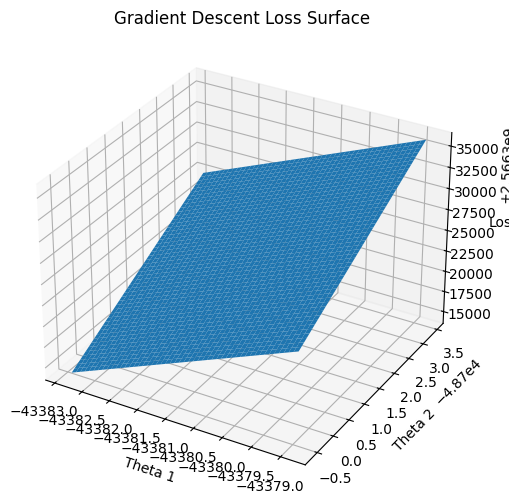

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    T1,
    T2,
    loss_surface
)

ax.set_xlabel("Theta 1")
ax.set_ylabel("Theta 2")
ax.set_zlabel("Loss")

ax.set_title("Gradient Descent Loss Surface")

plt.savefig(
    "loss_surface.png",
    dpi=300
)

plt.show()

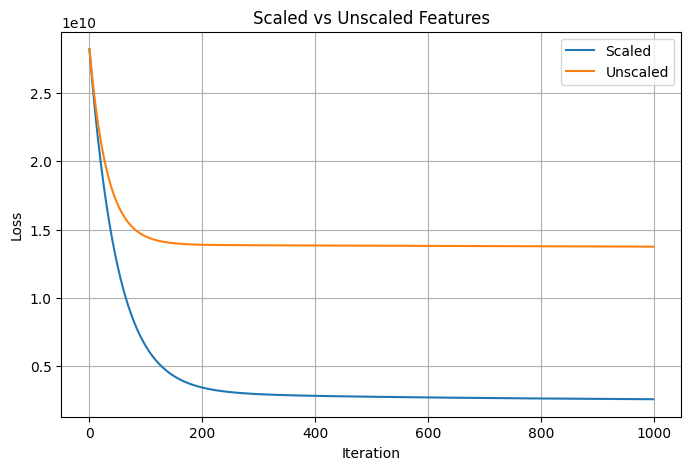

In [30]:
# ==========================================
# Scaled vs Unscaled Features
# ==========================================

_, scaled_loss = gradient_descent(
    X_train_final,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

X_train_unscaled = np.c_[
    np.ones(X_train.shape[0]),
    X_train
]

_, unscaled_loss = gradient_descent(
    X_train_unscaled,
    y_train,
    learning_rate=0.000000001,
    iterations=1000
)

plt.figure(figsize=(8, 5))

plt.plot(scaled_loss, label="Scaled")
plt.plot(unscaled_loss, label="Unscaled")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Scaled vs Unscaled Features")

plt.legend()
plt.grid(True)

plt.savefig(
    "scaled_vs_unscaled.png",
    dpi=300
)

plt.show()

In [31]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [32]:
mae_normal = mean_absolute_error(
    y_test, y_test_pred_normal
)

mae_gd = mean_absolute_error(
    y_test, y_test_pred_gd
)

mae_sklearn = mean_absolute_error(
    y_test, y_test_pred_sklearn
)

In [33]:
# ==========================================
# SECTION G — FINAL EVALUATION
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Normal Equation",
        "Gradient Descent",
        "Scikit-learn"
    ],
    "MSE": [
        test_mse_normal,
        test_mse_gd,
        test_mse_sklearn
    ],
    "RMSE": [
        test_rmse_normal,
        test_rmse_gd,
        test_rmse_sklearn
    ],
    "R2": [
        test_r2_normal,
        test_r2_gd,
        test_r2_sklearn
    ],
    "MAE": [
        mae_normal,
        mae_gd,
        mae_sklearn
    ]
})

print(results)

              Model           MSE          RMSE        R2           MAE
0   Normal Equation  4.867205e+09  69765.360222  0.619506  50352.228258
1  Gradient Descent  5.149828e+09  71762.304976  0.597412  51945.741289
2      Scikit-learn  4.867205e+09  69765.360222  0.619506  50352.228258


In [34]:
print(results.round(2))

              Model           MSE      RMSE    R2       MAE
0   Normal Equation  4.867205e+09  69765.36  0.62  50352.23
1  Gradient Descent  5.149828e+09  71762.30  0.60  51945.74
2      Scikit-learn  4.867205e+09  69765.36  0.62  50352.23
